# Creating West Boundary Conditions for the Elkhorn Slough MITgcm Model

This notebook creates simple west-boundary files for the Elkhorn Slough model.

The model bathymetry was designed so that only the western edge has wet cells touching the domain boundary. This western boundary represents exchange with Monterey Bay. The north, south, and east boundaries are closed.

The boundary files generated here are:

- `THETA_west_relax.bin`
- `SALT_west_relax.bin`
- `DO_west_relax.bin`
- `mask_west.bin`

Each file has shape:

`(Nr, Ny) = (5, 240)`

where `Nr = 5` vertical layers and `Ny = 240` grid cells along the west boundary.

The temperature, salinity, and dissolved oxygen boundary values are extracted from the updated initial condition fields at the west edge of the domain.

In [15]:
# -----------------------------
# Imports
# -----------------------------

import os
import numpy as np
import matplotlib.pyplot as plt

Next, define the location of the input directory for the model. This is the same directory that holds the bathymetry file generated in the previous notebooks for this model example.

In [16]:
# -----------------------------
# File paths
# -----------------------------

# Folder where model input files are stored
input_dir = r"C:\Users\rilee\MS 274\Final_Project\input"

# Output folder for OBCS files
obcs_dir = os.path.join(input_dir, "obcs")
os.makedirs(obcs_dir, exist_ok=True)

print("Input directory:", input_dir)
print("OBCS output directory:", obcs_dir)

Input directory: C:\Users\rilee\MS 274\Final_Project\input
OBCS output directory: C:\Users\rilee\MS 274\Final_Project\input\obcs


## Constructing the Boundary Conditions

The western edge of the model domain represents the connection between Elkhorn Slough and Monterey Bay. The corrected bathymetry has wet cells on the west boundary and closed cells on the north, south, and east boundaries.

For this first implementation, the west boundary temperature, salinity, and dissolved oxygen fields are taken directly from the corresponding initial condition fields. This creates a steady boundary condition that is consistent with the model initialization.

### Step 1: Define Model Grid

In [17]:
# -----------------------------
# Recreate model grid
# -----------------------------

xgOrigin = -121.795
ygOrigin = 36.8

Nx = 360
Ny = 240
Nr = 5

delX = 0.0001555555555555483
delY = 0.00025416666666666643

rxc = xgOrigin + (np.arange(Nx) + 0.5) * delX
ryc = ygOrigin + (np.arange(Ny) + 0.5) * delY

XC, YC = np.meshgrid(rxc, ryc)

print("XC shape:", XC.shape)
print("YC shape:", YC.shape)

# -----------------------------
# Read final MITgcm bathymetry
# -----------------------------

bathy_file = os.path.join(input_dir, "slough_bathymetry.bin")

bathy = np.fromfile(bathy_file, dtype=">f4").reshape((Ny, Nx))

print("bathy shape:", bathy.shape)
print("NaN count:", np.isnan(bathy).sum())
print("min/max:", np.nanmin(bathy), np.nanmax(bathy))
print("wet cells:", np.sum(bathy < 0))
print("land cells:", np.sum(bathy == 0))
print("positive bad cells:", np.sum(bathy > 0))

XC shape: (240, 360)
YC shape: (240, 360)
bathy shape: (240, 360)
NaN count: 0
min/max: -29.71549 0.0
wet cells: 6399
land cells: 80001
positive bad cells: 0


In [18]:
# -----------------------------
# Create wet mask from bathymetry
# -----------------------------

# MITgcm bathymetry convention:
#   bathy < 0 means water
#   bathy = 0 means land

mask2d = (bathy < 0).astype(np.int8)

print("mask2d shape:", mask2d.shape)
print("wet cells:", np.sum(mask2d == 1))
print("land cells:", np.sum(mask2d == 0))

mask2d shape: (240, 360)
wet cells: 6399
land cells: 80001


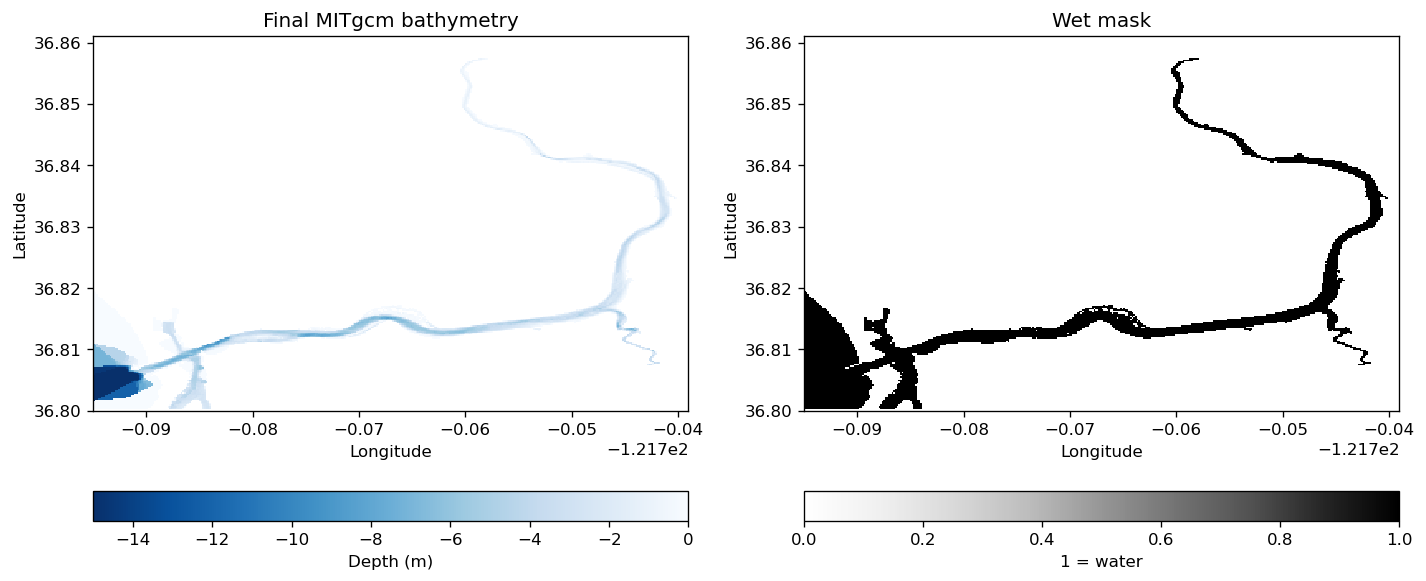

In [19]:
# -----------------------------
# Plot bathymetry and wet mask
# -----------------------------

bathy_plot = np.ma.masked_where(bathy == 0, bathy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

cmap_bathy = plt.get_cmap("Blues_r").copy()
cmap_bathy.set_bad("white")

im0 = axes[0].pcolormesh(
    XC, YC, bathy_plot,
    shading="auto",
    cmap=cmap_bathy,
    vmin=-15,
    vmax=0
)
fig.colorbar(im0, ax=axes[0], orientation="horizontal", label="Depth (m)")
axes[0].set_title("Final MITgcm bathymetry")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

im1 = axes[1].pcolormesh(
    XC, YC, mask2d,
    shading="auto",
    cmap="Greys",
    vmin=0,
    vmax=1
)
fig.colorbar(im1, ax=axes[1], orientation="horizontal", label="1 = water")
axes[1].set_title("Wet mask")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [20]:
# -----------------------------
# Check wet cells on model boundaries
# -----------------------------

wet = mask2d == 1

west_edge  = wet[:, 0]
east_edge  = wet[:, -1]
south_edge = wet[0, :]
north_edge = wet[-1, :]

print("Wet cells on west edge:", np.sum(west_edge))
print("Wet cells on east edge:", np.sum(east_edge))
print("Wet cells on south edge:", np.sum(south_edge))
print("Wet cells on north edge:", np.sum(north_edge))

print("\nWest edge wet j indices, Python 0-based:")
print(np.where(west_edge)[0])

print("\nWest edge wet j indices, MITgcm/Fortran 1-based:")
print(np.where(west_edge)[0] + 1)

Wet cells on west edge: 76
Wet cells on east edge: 0
Wet cells on south edge: 0
Wet cells on north edge: 0

West edge wet j indices, Python 0-based:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76]

West edge wet j indices, MITgcm/Fortran 1-based:
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77]


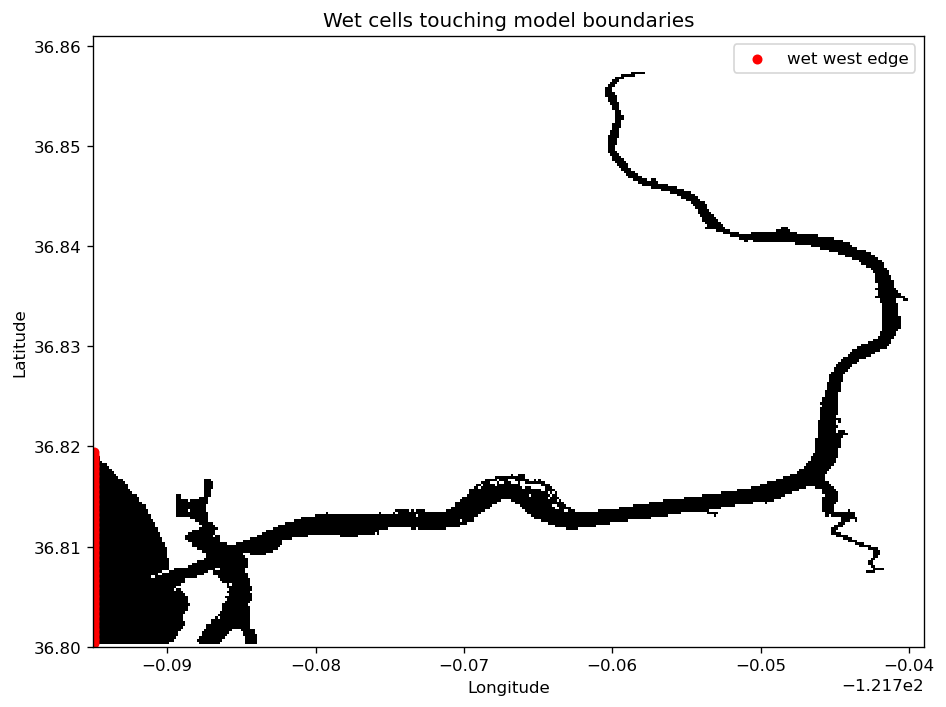

In [21]:
# -----------------------------
# Plot wet boundary cells
# -----------------------------

plt.figure(figsize=(8, 6), dpi=120)

plt.pcolormesh(
    XC, YC, wet,
    shading="auto",
    cmap="Greys"
)

plt.scatter(
    XC[west_edge, 0],
    YC[west_edge, 0],
    color="red",
    s=25,
    label="wet west edge"
)

plt.title("Wet cells touching model boundaries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# Generate OB_Iwest line for data.obcs
# -----------------------------
# MITgcm's OB_Iwest array has length Ny.
#
# For each j index:
#   1   means the west boundary is open at i=1
#   -99 means no open boundary at that j index
#
# This makes only the wet west-edge cells open.

ob_iwest = np.where(west_edge, 1, -99)

def compress_fortran_repeats(vals):
    """
    Convert an array like [-99, -99, 1, 1, 1] into
    Fortran repetition syntax like '2*-99, 3*1'.
    """
    pieces = []
    start = 0

    while start < len(vals):
        value = vals[start]
        end = start + 1

        while end < len(vals) and vals[end] == value:
            end += 1

        count = end - start
        pieces.append(f"{count}*{int(value)}")
        start = end

    return ", ".join(pieces)

ob_iwest_line = "OB_Iwest = " + compress_fortran_repeats(ob_iwest) + ","

print("Copy this line into data.obcs:")
print(ob_iwest_line)

Copy this line into data.obcs:
OB_Iwest = 1*-99, 76*1, 163*-99,


### Step 2: Create tapering relaxation mask

In [23]:
# -----------------------------
# Read updated initial condition files
# -----------------------------

def read_bin(file_path, shape):
    arr = np.fromfile(file_path, dtype=">f4")
    expected = np.prod(shape)

    if arr.size != expected:
        raise ValueError(
            f"{file_path} has {arr.size} values, expected {expected}"
        )

    return arr.reshape(shape)

theta_init = read_bin(
    os.path.join(input_dir, "THETA_IC.bin"),
    (Nr, Ny, Nx)
)

salt_init = read_bin(
    os.path.join(input_dir, "SALT_IC.bin"),
    (Nr, Ny, Nx)
)

do_init = read_bin(
    os.path.join(input_dir, "DO_IC.bin"),
    (Nr, Ny, Nx)
)

print("theta_init shape:", theta_init.shape)
print("salt_init shape:", salt_init.shape)
print("do_init shape:", do_init.shape)

print("theta NaNs:", np.isnan(theta_init).sum())
print("salt NaNs:", np.isnan(salt_init).sum())
print("DO NaNs:", np.isnan(do_init).sum())

theta_init shape: (5, 240, 360)
salt_init shape: (5, 240, 360)
do_init shape: (5, 240, 360)
theta NaNs: 0
salt NaNs: 0
DO NaNs: 0


In [24]:
# -----------------------------
# Extract west boundary fields and save OBCS files
# -----------------------------
# West boundary shape:
#   (Nr, Ny) = (5, 240)
#
# These files contain values along the full west edge. For j rows where
# the west edge is land/closed, values are set to 0.

theta_west = theta_init[:, :, 0].copy()
salt_west  = salt_init[:, :, 0].copy()
do_west    = do_init[:, :, 0].copy()

# Apply west-edge wet mask so closed/land rows are zero.
# west_edge has shape (Ny,), so west_edge[np.newaxis, :] broadcasts over Nr.
theta_west = np.where(west_edge[np.newaxis, :], theta_west, 0.0)
salt_west  = np.where(west_edge[np.newaxis, :], salt_west, 0.0)
do_west    = np.where(west_edge[np.newaxis, :], do_west, 0.0)

# Boundary mask: 1 where west boundary is open, 0 elsewhere.
mask_west = np.tile(west_edge[np.newaxis, :], (Nr, 1)).astype(np.float32)

# Save files
theta_west.astype(">f4").tofile(os.path.join(obcs_dir, "THETA_west_relax.bin"))
salt_west.astype(">f4").tofile(os.path.join(obcs_dir, "SALT_west_relax.bin"))
do_west.astype(">f4").tofile(os.path.join(obcs_dir, "DO_west_relax.bin"))
mask_west.astype(">f4").tofile(os.path.join(obcs_dir, "mask_west.bin"))

print("theta_west shape:", theta_west.shape)
print("salt_west shape:", salt_west.shape)
print("do_west shape:", do_west.shape)
print("mask_west shape:", mask_west.shape)

print("Open west mask cells:", np.sum(mask_west == 1))
print("Closed west mask cells:", np.sum(mask_west == 0))

theta_west shape: (5, 240)
salt_west shape: (5, 240)
do_west shape: (5, 240)
mask_west shape: (5, 240)
Open west mask cells: 380
Closed west mask cells: 820


### Step 6: Plotting the Boundary Fields
Now that the fields have been generated, I will plot them to ensure they look as expected. First, I'll generate some metadata for each one:

In [25]:
# -----------------------------
# Plot metadata
# -----------------------------

meta_dict = {
    "THETA": (15, 20, "turbo", "°C"),
    "SALT":  (32, 35, "viridis", "PSU"),
    "DO":    (0, 10, "seismic", "mg/L"),
}

Then, I'll create all of the subplots:

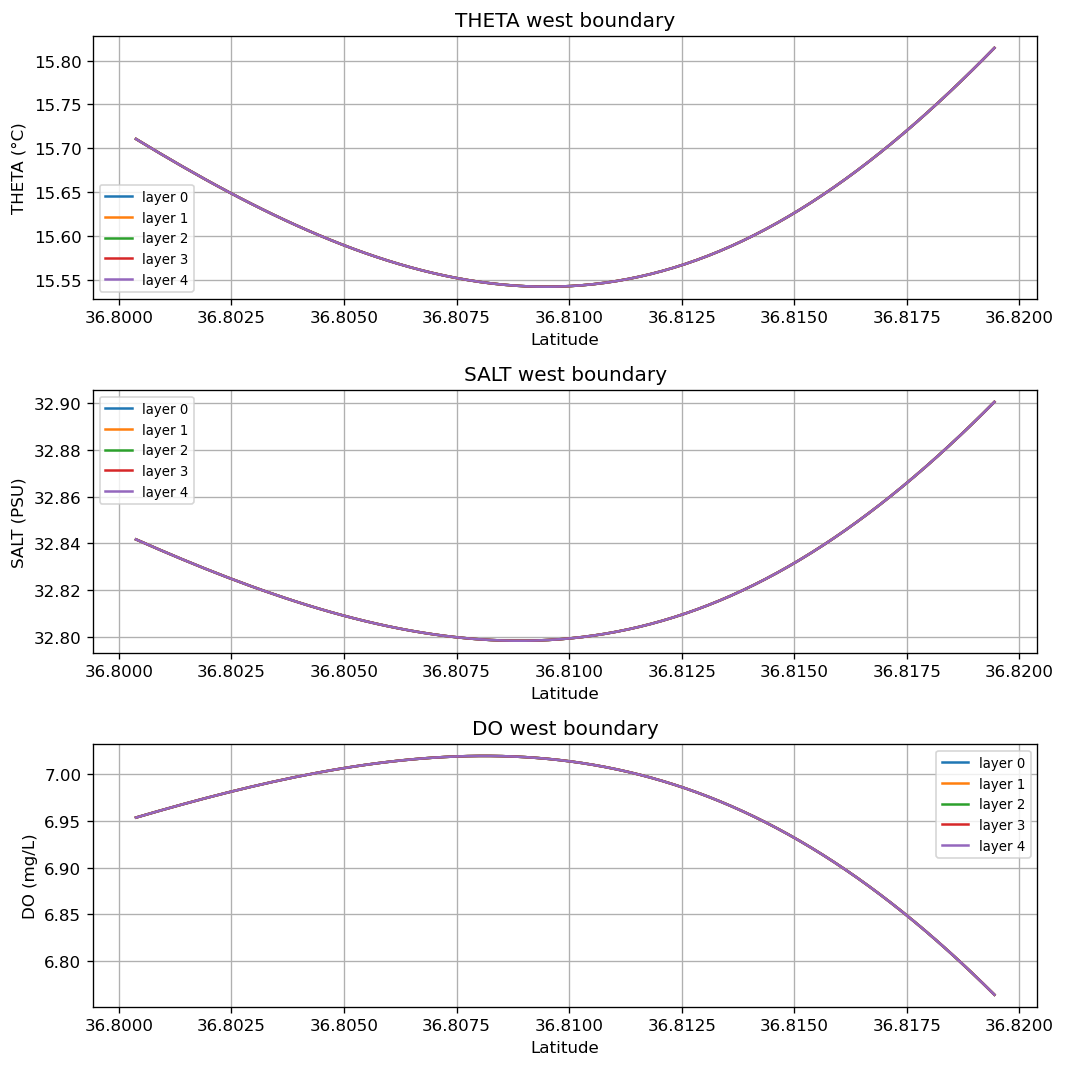

In [26]:
# -----------------------------
# Plot west boundary fields
# -----------------------------

variable_names = ["THETA", "SALT", "DO"]

file_dict = {
    "THETA": "THETA_west_relax.bin",
    "SALT":  "SALT_west_relax.bin",
    "DO":    "DO_west_relax.bin",
}

fig, axes = plt.subplots(len(variable_names), 1, figsize=(9, 9), dpi=120)

x = YC[:, 0]  # latitude along west boundary

for ax, variable_name in zip(axes, variable_names):
    file_path = os.path.join(obcs_dir, file_dict[variable_name])

    boundary_grid = np.fromfile(file_path, dtype=">f4").reshape((Nr, Ny))

    # Mask closed boundary rows for plotting
    boundary_plot = np.ma.masked_where(mask_west == 0, boundary_grid)

    for k in range(Nr):
        ax.plot(x, boundary_plot[k, :], label=f"layer {k}")

    units = meta_dict[variable_name][3]

    ax.set_xlabel("Latitude")
    ax.set_ylabel(f"{variable_name} ({units})")
    ax.set_title(f"{variable_name} west boundary")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

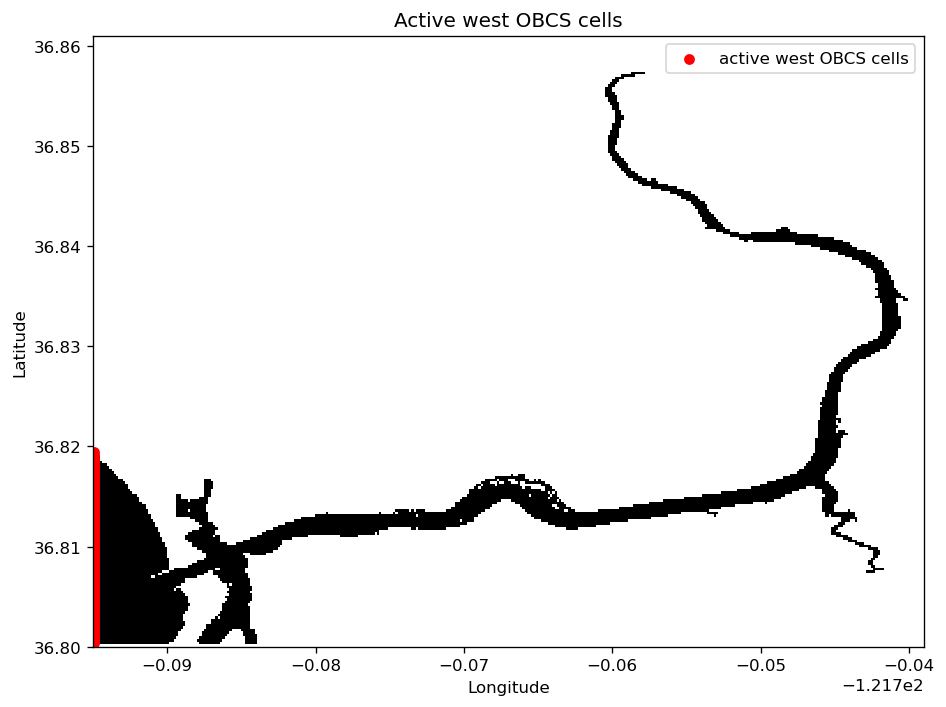

In [27]:
# -----------------------------
# Plot west boundary locations on map
# -----------------------------

plt.figure(figsize=(8, 6), dpi=120)

plt.pcolormesh(
    XC,
    YC,
    mask2d,
    shading="auto",
    cmap="Greys"
)

plt.scatter(
    XC[west_edge, 0],
    YC[west_edge, 0],
    color="red",
    s=30,
    label="active west OBCS cells"
)

plt.title("Active west OBCS cells")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# -----------------------------
# Check OBCS file sizes
# -----------------------------

files_to_check = {
    "THETA_west_relax.bin": Nr * Ny,
    "SALT_west_relax.bin": Nr * Ny,
    "DO_west_relax.bin": Nr * Ny,
    "mask_west.bin": Nr * Ny,
}

for fname, expected_values in files_to_check.items():
    path = os.path.join(obcs_dir, fname)

    if not os.path.exists(path):
        print(f"MISSING: {path}")
        continue

    arr = np.fromfile(path, dtype=">f4")

    print(
        f"{fname:22s}",
        f"values={arr.size:8d}",
        f"expected={expected_values:8d}",
        f"nan={np.isnan(arr).sum():5d}",
        f"min={np.nanmin(arr):10.4f}",
        f"max={np.nanmax(arr):10.4f}"
    )

THETA_west_relax.bin   values=    1200 expected=    1200 nan=    0 min=    0.0000 max=   15.8145
SALT_west_relax.bin    values=    1200 expected=    1200 nan=    0 min=    0.0000 max=   32.9003
DO_west_relax.bin      values=    1200 expected=    1200 nan=    0 min=    0.0000 max=    7.0190
mask_west.bin          values=    1200 expected=    1200 nan=    0 min=    0.0000 max=    1.0000


## Run-time considerations

These files are intended for the MITgcm OBCS package. The model bathymetry has been cleaned so that only the west edge contains wet boundary cells. The western boundary represents ocean exchange with Monterey Bay.

In `data.pkg`, OBCS must be enabled:

```fortran
useOBCS = .TRUE.,